# Project card

**The paper:** 
>Volatility of Mutator Phenotypes at Single
Cell Resolution

**The data object:**
>Novel mutation count per cell division for all lineages

**The random variable chosen:**

>Mutation count

**What the paper does:**
>Models mutation rate in mutator phenotypes of yeast. It counts the number of mutations in each cell division and fits it to a 2-Poisson model.

**The generative model proposed:**
> 2-poisson model https://link.springer.com/rwe/10.1007/978-0-387-39940-9_920

**Parameters and assumptions:**
> total count of cells = N

**The forward simulation:**
> Monte-Carlo simulation; Grid search to find paramters for 2 poisson

**The parameterization/fitting:**

**What/if the model adds to the paper:**

**Model limitations/how it breaks:**

---

### Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

### Functions

In [2]:
def mean(counts):
    """The mean of a list of counts."""
    return sum(counts) / len(counts)

def std_dev(counts):
    """The standard deviation of a list of counts."""
    m = mean(counts)
    total = 0.0
    for x in counts:
        total = total + (x - m) ** 2
    return math.sqrt(total / len(counts))

def factorial(x):
    """x! as a product, 0! = 1."""
    total = 1
    for k in range(1, x + 1):
        total = total * k
    return total

def poisson(x, theta):
    """p(x | theta) = theta^x e^(-theta) / x!  the probability of x counts in a cell at rate theta."""
    return theta ** x * math.exp(-theta) / factorial(x)

def likelihood(counts, theta):
    """L(theta) = p(x | theta) = the product over cells of p(x_i | theta)."""
    total = 1.0
    for x in counts:
        total = total * poisson(x, theta)
    return total

def nll(counts, theta):
    """NLL(theta) = - the sum over cells of ln p(x_i | theta)."""
    total = 0.0
    for x in counts:
        total = total - math.log(poisson(x, theta))
    return total

def position_of_min(values):
    """The index of the smallest entry: the position, not the value."""
    best = 0
    for j in range(len(values)):
        if values[j] < values[best]:
            best = j
    return best

A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32
seed = 100

def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (a * state + c) % m

def uniforms(k, seed):
    """A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."""
    out = [0.0] * k
    state = seed
    for i in range(k):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        out[i] = state / M_LCG
    return out



### Data

#### 1. Read Files

In [3]:
df = pd.read_excel("data/mutation_counts.xlsx", header=0, skiprows=[1], index_col=0)
df = df.replace(r"^\s*$", np.nan, regex=True)
df = df.astype(float)

lineages = [list(df[column].dropna()) for column in df.columns]
counts = [int(y) for x in lineages for y in x]

genome_size = 1.02E+07

# Print the data
print("Data Matrix:")
print(df,"\n")
print("Lineage Cell Division Counts:")
print("\n".join(str(lin) for lin in lineages), "\n")
print("Flattened Counts:")
print(counts, len(counts))

Data Matrix:
           B    C    D     E   F*   G1   G2    H
Lineage                                         
3        0.0  3.0  2.0   2.0  3.0  1.0  NaN  7.0
4        2.0  7.0  2.0   3.0  7.0  1.0  NaN  0.0
5        0.0  6.0  0.0   1.0  1.0  0.0  7.0  2.0
6        3.0  0.0  3.0   6.0  3.0  0.0  6.0  0.0
7        2.0  0.0  0.0   0.0  2.0  3.0  0.0  4.0
8        4.0  2.0  0.0   0.0  NaN  6.0  5.0  3.0
9        1.0  3.0  1.0   0.0  NaN  4.0  0.0  4.0
10       3.0  4.0  1.0   8.0  0.0  5.0  NaN  1.0
11       4.0  4.0  4.0   0.0  5.0  3.0  NaN  4.0
12       NaN  6.0  5.0  10.0  2.0  5.0  NaN  1.0
13       NaN  5.0  3.0   NaN  3.0  4.0  NaN  1.0
14       NaN  1.0  0.0   NaN  1.0  NaN  NaN  3.0
15       NaN  0.0  9.0   NaN  NaN  NaN  NaN  NaN
16       NaN  NaN  4.0   NaN  NaN  NaN  NaN  NaN
17       NaN  NaN  2.0   NaN  NaN  NaN  NaN  NaN 

Lineage Cell Division Counts:
[0.0, 2.0, 0.0, 3.0, 2.0, 4.0, 1.0, 3.0, 4.0]
[3.0, 7.0, 6.0, 0.0, 0.0, 2.0, 3.0, 4.0, 4.0, 6.0, 5.0, 1.0, 0.0]
[2.0, 2.0,

#### 2. Summary Statistics

Mean: 2.7411764705882353 mutations/cell division
Mean: 2.6874279123414073e-07 mutations/cell division/bp
Standard Deviation: 2.3919125558306864
Variance: 5.721245674740486
Variance is higher than mean, thus overdispersed


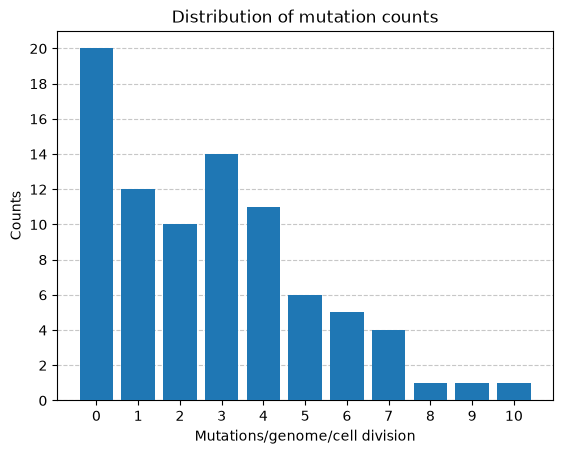

In [4]:
max_mutation_count = max(counts)
mutation_counts = [0] * (max_mutation_count + 1)

for count in counts:
    mutation_counts[count] += 1 

mean_count = mean(counts)
sigma = std_dev(counts)
variance = sigma ** 2
mutation_rate = mean_count/genome_size
print(f"Mean: {mean_count} mutations/cell division")
print(f"Mean: {mutation_rate} mutations/cell division/bp")
print(f"Standard Deviation: {sigma}")
print(f"Variance: {variance}")
print("Variance is higher than mean, thus overdispersed")

# mutation_prob =  [ mutation_count/sum(mutation_counts) for mutation_count in mutation_counts ]

fig, ax = plt.subplots()
ax.bar(range(len(mutation_counts)), mutation_counts, zorder=3)
ax.set_xlabel("Mutations/genome/cell division")
ax.set_ylabel("Counts")
ax.set_xticks(range(0,11))
ax.set_yticks(range(0,22,2))
ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax.set_title("Distribution of mutation counts")
plt.show()

#### 3. Models

##### 3.1 1-Poisson Model

theta_hat 2.7399999999999998
NLL Score 199.25319597233133
Mean:  2.7411764705882353
NLL Score 199.2531745069619


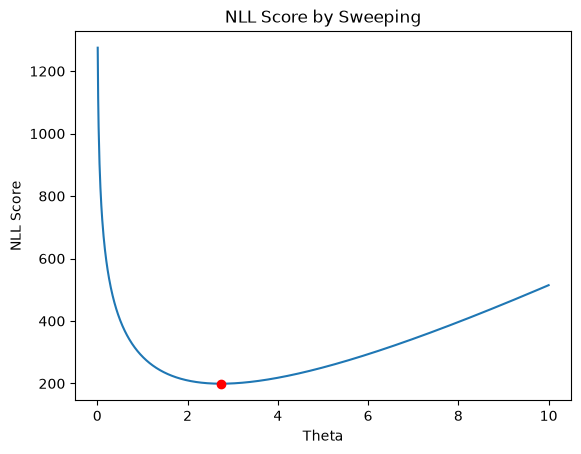

In [5]:
likelihoods = [0] * 1000
nlls = [0] * 1000
thetas = [0] * 1000
theta_start = 0.01
dtheta = 0.01

# print(likelihood(counts, mean_count))
for i in range(len(thetas)):
    thetas[i] = theta_start + (i * dtheta)
    # likelihoods[i] = likelihood(counts, thetas[i])
    nlls[i] = nll(counts, thetas[i])
    
best = position_of_min(nlls)
theta_hat = thetas[best]
best_score = nlls[best]
print("theta_hat", theta_hat)
print("NLL Score", best_score)
print("Mean: ", mean_count)
print("NLL Score", nll(counts, mean_count))

fig, ax = plt.subplots()
ax.plot(thetas, nlls)
ax.plot(theta_hat, best_score, 'ro')
ax.set_xlabel("Theta")
ax.set_ylabel("NLL Score")
ax.set_title("NLL Score by Sweeping")
plt.show()

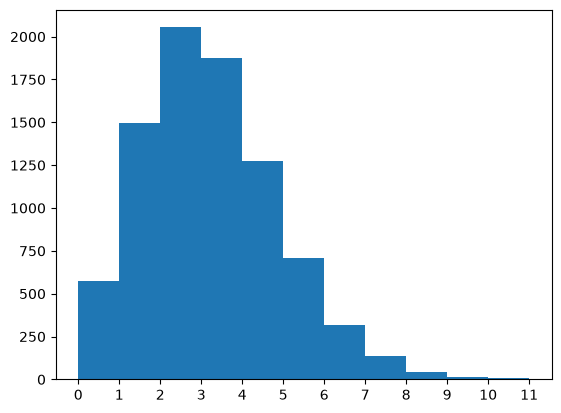

In [17]:
# Monte-Carlo for 1 Poisson

# Probabiity of mutation per base is your theta. Give a genome size and divide the cell.


def simuate_count(lam, state):
    state = lcg(state, A_LCG, C_LCG, M_LCG)
    r = state/M_LCG
    total = poisson(0, lam)
    k = 0
    while r > total:
        k += 1
        total = total + poisson(k, lam)
    return k, state


cell_divisions = 85
state = seed

def experiment(lam, cell_divisions, state):
    simulated_counts = [0] * cell_divisions
   
    for i in range(len(simulated_counts)):
        sim_count, state = simuate_count(lam, state)
        simulated_counts[i] = (sim_count)
        
    return simulated_counts, state

simulated_runs = []

for i in range(100):
    simulated_counts, state = experiment(theta_hat, cell_divisions, state)
    simulated_runs.append(simulated_counts)
    
fig, ax = plt.subplots()
# simulated_runs_avg = 
simulated_runs_flat = [y for x in simulated_runs for y in x]
ax.hist(simulated_runs_flat, bins=range(min(simulated_runs_flat), max(simulated_runs_flat)+1, 1))
ax.set_xticks((range(min(simulated_runs_flat), max(simulated_runs_flat)+1, 1)))

##### 3.2 2-Poisson Model

#### Backwards - estimating the model’s parameter/s

In [ ]:
def nll_mix_poisson(counts, lambda1, lambda2, pi):
    """NLL(theta) = - the sum over cells of ln p(x_i | theta)."""
    total = 0.0
    for x in counts:
        total = total - math.log(pi * poisson(x, lambda1) + (1-pi) * poisson(x, lambda2))
    return total

lambda1 = np.arange(0, 2, 0.02).tolist()
lambda2 = np.arange(1 , 5, 0.02).tolist()
pi = np.arange(0.05 , 0.95, 0.05).tolist()

flag = True
for k in pi:
  for j in lambda2:
    for i in lambda1:
        nll_mix_poisson_score = nll_mix_poisson(counts,i,j,k)
        if flag:
            minimum = nll_mix_poisson_score
            lambda1_hat = i
            lambda2_hat = j
            pi_hat = k
            flag = False
        elif nll_mix_poisson_score < minimum:
            minimum = nll_mix_poisson_score
            lambda1_hat = i
            lambda2_hat = j
            pi_hat = k

print("lambda1_hat =", round(lambda1_hat, 3))
print("lambda2_hat =", round(lambda2_hat, 3))
print("pi_hat =", round(pi_hat, 3))

lambda1_hat = 0.44
lambda2_hat = 3.94
pi_hat = 0.35


In [ ]:
y_mix_poisson_lik = [0] * len(counts)
y_mix_poisson_test = [0] * len(counts)

for i in range(len(counts)):
    y_mix_poisson_lik[i] += pi_hat * poisson(counts[i], lambda1_hat) + (1-pi_hat) * poisson(counts[i], lambda2_hat)
    y_mix_poisson_test[i] += 0.35 * poisson(counts[i], 0.5) + (1-0.35) * poisson(counts[i], 3.5)
    #y_mix_poisson_test[i] += 0.2 * poisson(counts[i], lambda1_hat) + (1-0.2) * poisson(counts[i], lambda2_hat)


y_mix_poisson_lik = [x*N for x in y_mix_poisson_lik]
y_mix_poisson_test = [x*N for x in y_mix_poisson_test]

plt.figure(figsize=(14, 5))
#plt.bar(counts, y_mix_poisson)
plt.bar(np.array(range((max_mutation_count)+1)) - 0.3, mutation_counts, width=0.3, label='Data', color='red')
plt.bar(np.array(counts) , y_mix_poisson_lik, width=0.3, label='MAX LIKE', color='blue')
plt.bar(np.array(counts) + 0.3, y_mix_poisson_test, width=0.3, label='TEST', color='green')
plt.xlabel("Mutations/genome/cell division")
plt.ylabel("Counts")
plt.xticks(range(0,11));
plt.yticks(range(0,22,2));
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.title("Distribution of mutation counts")
plt.legend()
plt.show()

NameError: name 'N' is not defined